In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

 ==============Data Loading=================

In [9]:
df = pd.read_csv("../data/Mall_Customers.csv")

================Data Exploration (EDA)==================

In [11]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
df.shape

(200, 5)

In [14]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [16]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [18]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

====================Data Visualization===============

In [24]:
x = df[['Annual Income (k$)' ,'Spending Score (1-100)']]

In [25]:
print(x)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


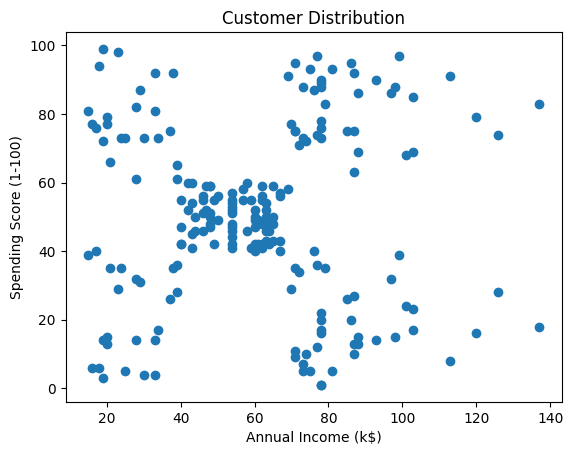

In [27]:
plt.Figure(figsize=(8,6))
plt.scatter(
    x['Annual Income (k$)'],
    x['Spending Score (1-100)']
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution')
plt.show()

==================Elbom Method=====================

In [30]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )
    kmeans.fit(x)
    kmeans.inertia_
    wcss.append(kmeans.inertia_)

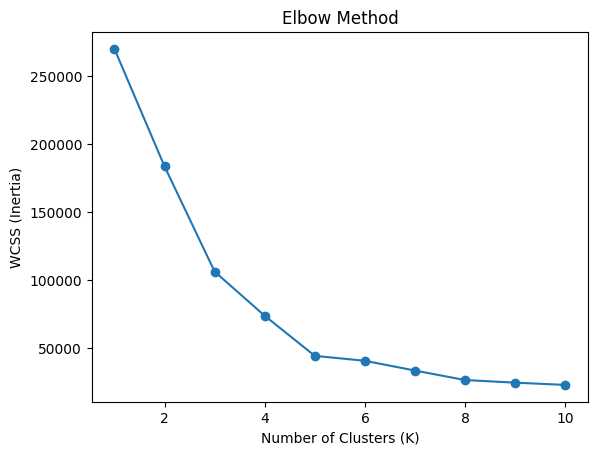

In [31]:
plt.Figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

In [32]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)



In [33]:
y_kmeans = kmeans.fit_predict(x)
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


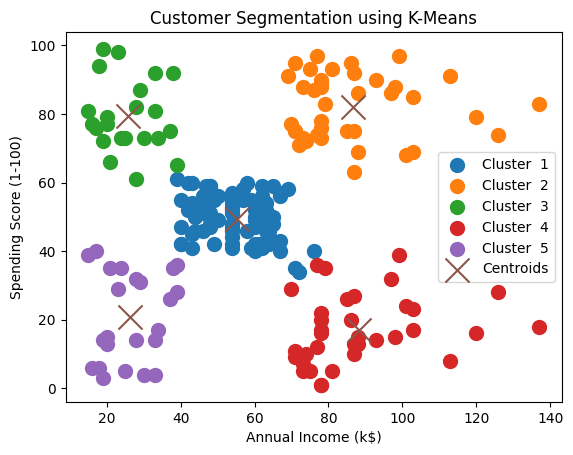

In [44]:
plt.Figure(figsize=(10,7))
for i in range(5):

    plt.scatter(
    x.iloc[y_kmeans==i ,0],
    x.iloc[y_kmeans==i ,1],
    s=100,
    label = f'Cluster  {i + 1}'
    )
plt.scatter( 
    kmeans .cluster_centers_[: , 0],
    kmeans.cluster_centers_[: , 1],
    s=300,
    marker='x',
    label='Centroids'
)
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.savefig("../images/customer_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
df["Cluster"] = y_kmeans

In [39]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [40]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [43]:
df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Number of Customers"})

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


# Business Insights & Recommendations

The K-Means clustering algorithm segmented customers into **five distinct groups** based on their **Annual Income** and **Spending Score**.

---

## Cluster 0 – Medium Income, Medium Spending

**Characteristics:**
- Average Age: **42.7 years**
- Average Annual Income: **55.3 k$**
- Average Spending Score: **49.5**

**Business Recommendation:**
- Maintain customer engagement through seasonal promotions.
- Recommend products based on previous purchases.
- Encourage higher spending using bundle offers and loyalty rewards.

---

## Cluster 1 – High Income, High Spending

**Characteristics:**
- Average Age: **32.7 years**
- Average Annual Income: **86.5 k$**
- Average Spending Score: **82.1**

**Business Recommendation:**
- These are the company's most valuable customers.
- Offer VIP memberships and exclusive rewards.
- Provide personalized recommendations and premium products.
- Focus on retaining these customers through exceptional service.

---

## Cluster 2 – Low Income, High Spending

**Characteristics:**
- Average Age: **25.3 years**
- Average Annual Income: **25.7 k$**
- Average Spending Score: **79.4**

**Business Recommendation:**
- Promote affordable products and special offers.
- Introduce installment payment options.
- Create loyalty programs to maintain their engagement.

---

## Cluster 3 – High Income, Low Spending

**Characteristics:**
- Average Age: **41.1 years**
- Average Annual Income: **88.2 k$**
- Average Spending Score: **17.1**

**Business Recommendation:**
- Encourage purchases through personalized marketing campaigns.
- Send targeted discounts and premium product recommendations.
- Analyze why these customers are not spending despite their high income.

---

## Cluster 4 – Low Income, Low Spending

**Characteristics:**
- Average Age: **45.2 years**
- Average Annual Income: **26.3 k$**
- Average Spending Score: **20.9**

**Business Recommendation:**
- Focus on low-cost products and discount campaigns.
- Offer budget-friendly packages.
- Improve customer retention through reward programs.

---

# Conclusion

The Elbow Method identified **K = 5** as the optimal number of clusters.

Customer segmentation enables businesses to understand customer behavior and implement targeted marketing strategies. By tailoring offers for each customer segment, businesses can improve customer satisfaction, increase sales, and strengthen long-term customer relationships.